# Microcanonical vs grand-canonical ensembles in practice

A practical, reproducible comparison of the current MENoBiS **grand-canonical**
(GC) and **microcanonical** (micro) ensembles: end-to-end public-API compute
cost, constraint recovery, and higher-order observables over a fixed sparse
scaling regime ($N\in\{100,500,2000\}$, $\langle k\rangle\approx 8$,
$T/E\approx 8$).

Throughout the notebook:

$$
\boxed{
\text{same target constraints}
\neq
\text{same finite-size ensemble}
\neq
\text{same higher-order predictions}
}
$$

Grand-canonical: fit *soft* expectation constraints, then draw independent
networks from the fitted law, then average. Microcanonical: construct/sample
under the *documented hard constraints* (MCMC or direct where available), then
average.

This notebook is a **finite-size practical study**. It does **not** test the
fixed-$N$, large-$T$ ensemble-equivalence theorem (see
[section 11](#11-relation-to-ensemble-equivalence) and the
[Ensemble equivalence](../../science/ensemble-equivalence.md) page).


## 1. What is being compared?

The public MENoBiS workflow exposes two families of routes:

- **Grand-canonical (GC)** — `fit_model` adjusts Lagrange multipliers so that
  the *expected* values of the constraint statistics equal the target values
  (e.g. $\mathbb{E}[s_i]=s_i^{\star}$), then `sample_model` draws each
  node-pair independently from the fitted pair law. Constraints are matched
  **in expectation**; every finite realization fluctuates around them.
- **Microcanonical (micro)** — `sample_model` with
  `ensemble=MICROCANONICAL` constructs or samples networks whose constraint
  statistics are **exact, realization by realization** (where documented).

Both use the same three families ME (Poisson), B (Binomial on $M$ layers),
and W (Negative Binomial on $M$ layers), and the same six constraint families:
`STRENGTH`, `STRENGTH_COST`, `STRENGTH_EDGES`, `STRENGTH_DEGREE`,
`DEGREE_EVENTS`, `EDGES_EVENTS`.

The experiment answers exactly three questions:

1. **End-to-end speed**: how long does the current public API need to produce
   an ensemble average over 10 networks?
2. **Scientific differences**: do ensemble-averaged high-level observables
   (degree, strength, $Y_2$, $k_{NN}$, $s_{NN}$, realized cost) agree between
   the two ensembles?
3. **Scaling**: how do both answers change from $N=100$ through $N=2000$?

$\langle G\rangle$ denotes a 10-network ensemble average; $\mathrm{SD}$
and $\mathrm{SE}$ are the sample standard deviation and Monte Carlo standard
error of the mean across the ensemble.


## 2. Hard constraints and soft constraints

| Constraint | Grand-canonical | Microcanonical | Main comparison observables |
|---|---|---|---|
| `STRENGTH` | strengths matched in expectation | strengths exact | E, k, Y2, kNN, sNN |
| `STRENGTH_COST` | strengths and cost matched in expectation | strengths exact; cost matched in expectation by micro gamma fit | cost, E, k, Y2, kNN, sNN |
| `STRENGTH_EDGES` | strengths and E matched in expectation | strengths and E exact | k, Y2, kNN, sNN |
| `STRENGTH_DEGREE` | strengths and degree sequence matched in expectation | strengths and degree sequence exact | Y2, kNN, sNN |
| `DEGREE_EVENTS` | degrees and T matched in expectation | degrees and T exact | s, Y2, kNN, sNN |
| `EDGES_EVENTS` | E and T matched in expectation | E and T exact | k, s, Y2, kNN, sNN |

Important semantic point: **`STRENGTH_COST` cost is *not* exact** in the
microcanonical ensemble. The micro route fixes strengths exactly and performs
an internal gamma fit so that cost is matched *in expectation* (the same way GC
matches it). The notebook therefore reports realized vs target cost, never an
"exact cost" claim.

Because GC matches constraints in expectation and micro matches them
realization-by-realization, *nonlinear* observables (degree when not fixed,
$Y_2$, $k_{NN}$, $s_{NN}$, realized cost) need **not** agree between the two
ensembles. Finite-size disagreement is expected and is the object of study, not
a bug.


## 3. Experimental design

The mandatory matrix:

```
3 N values  (100, 500, 2000)
× 3 families (ME, B, W)
× 6 constraints
× 2 ensembles
× 10 samples
```

Same sparse regime at all $N$: `average_degree = 8.0`,
`events_per_edge = 8.0`, `self_loops = False`. Hence $E\approx 8N$,
$T\approx 64N$:

| N | E | directed density $E/(N(N-1))$ | T |
|---:|---:|---:|---:|
| 100 | 800 | 0.0808 | 6,400 |
| 500 | 4,000 | 0.0160 | 32,000 |
| 2000 | 16,000 | 0.0040 | 128,000 |

This is a **sparse-network scaling experiment** ($E=O(N)$, $T=O(N)$,
$\langle k^{out}\rangle\approx 8$, $T/E\approx 8$). It is *not* a
fixed-density experiment, *not* a large-$N$ thermodynamic-limit proof, and
*not* a large-$T$ ensemble-equivalence experiment.

One observed network per $N$ (seed `42 + n`) supplies the constraint
sequences; the same constraints are used for every family, constraint, and
ensemble. All sample seeds are deterministic (see the benchmark module's
`ensemble_seed`). GC and micro samples with equal sample indices are
independent draws with the same seed but different chain-length semantics —
they are **not** paired.

**MCMC budgets.** The micro routes expose `burn_in_sweeps` and
`sweeps_per_sample`. A mandatory within-micro stability gate (Section 14 of the
implementation plan) compared $D_{\mathrm{rel}}$ between budget pairs on the
extended ladder $(3{+}1) \to (10{+}2) \to (20{+}5) \to (50{+}10) \to
(200{+}50)$ at $N=100$ and selected the smallest budget whose ensemble agrees
with the next one within $0.05$. Where even the largest budget was not stable
(`unstable_at_max_budget`) or where feasibility caps apply at $N\ge 500$,
this notebook **explicitly flags** the cell's budget and instability in every
table and figure (see `metadata.json` → `budget_gate` / `budget_caps`).


In [1]:
RUN_FULL_BENCHMARK = False
# If True, re-runs the *same* benchmark functions behind the `all` CLI command:
# budget gate -> main matrix -> sparsity sensitivity. Heavy (hours); results are
# written into benchmarks/results/ensemble-comparison. MkDocs never triggers it.

if RUN_FULL_BENCHMARK:
    import benchmarks.ensemble_comparison as ec

    stop, chosen = ec.run_mcmc_budget_gate()
    ec.run_main_matrix(budget_overrides=chosen)
    ec.run_sparsity_sensitivity(warm=False)

import json
import uuid
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from menobis.models.spec import Constraint, Ensemble, ModelFamily
from menobis.routing import fit_model, sample_model
from menobis.analysis.stats import compute_all_stats
from menobis.utilities.synthetic import (
    generate_pa_geographic_network,
    derive_synthetic_constraints,
)

plt.rcParams["figure.dpi"] = 110

def _find_results() -> Path:
    # Locate the results dir from either the repo root or the notebook dir.
    cwd = Path.cwd()
    for parent in (cwd, *cwd.parents):
        candidate = parent / "benchmarks/results/ensemble-comparison"
        if candidate.exists():
            return candidate
    return cwd / "benchmarks/results/ensemble-comparison"

RESULTS = _find_results()
NODE_COUNTS = (100, 500, 2000)
FAMILIES = (ModelFamily.ME, ModelFamily.B, ModelFamily.W)
CONSTRAINTS = (
    Constraint.STRENGTH,
    Constraint.STRENGTH_COST,
    Constraint.STRENGTH_EDGES,
    Constraint.STRENGTH_DEGREE,
    Constraint.DEGREE_EVENTS,
    Constraint.EDGES_EVENTS,
)

def _npz() -> dict[str, np.ndarray]:
    path = RESULTS / "per-node-means.npz"
    if not path.exists() or path.stat().st_size == 0:
        return {}
    try:
        with np.load(path) as data:
            return {k: data[k].copy() for k in data.files}
    except (EOFError, OSError, ValueError):
        return {}

def _read(name: str) -> pd.DataFrame | None:
    path = RESULTS / name
    if not path.exists():
        return None
    return pd.read_csv(path)

def _spearman_ranks(values: np.ndarray) -> np.ndarray:
    order = np.argsort(values, kind="mergesort")
    ranks = np.empty_like(values, dtype=np.float64)
    ranks[order] = np.arange(1, len(values) + 1, dtype=np.float64)
    _, inverse = np.unique(values, return_inverse=True)
    for index in range(int(inverse.max()) + 1):
        mask = inverse == index
        if np.sum(mask) > 1:
            ranks[mask] = np.mean(ranks[mask])
    return ranks

def _spearman(a: np.ndarray, b: np.ndarray) -> float:
    if len(a) < 3:
        return float("nan")
    ra = _spearman_ranks(a)
    rb = _spearman_ranks(b)
    if np.std(ra) == 0.0 or np.std(rb) == 0.0:
        return float("nan")
    return float(np.corrcoef(ra, rb)[0, 1])

timing = _read("main-timings.csv")
science = _read("main-scientific-summary.csv")
comparison = _read("main-comparison.csv")
sparsity = _read("sparsity-sensitivity.csv")
gate = _read("mcmc-budget-gate.csv")
mins = _npz()
meta = None
if (RESULTS / "metadata.json").exists():
    meta = json.loads((RESULTS / "metadata.json").read_text())

HAVE_RESULTS = timing is not None and science is not None and comparison is not None

print("results found:", HAVE_RESULTS, "| run mode:", "live data" if HAVE_RESULTS else "reproduction instructions only")
if not HAVE_RESULTS:
    print()
    print("No benchmark results found at", RESULTS)
    print("Reproduce the full experiment (hours, heavy at N=2000) with:")
    print("    uv run python -m benchmarks.ensemble_comparison all")
    print("Cells below that require results will print 'no results' instead of figures.")


results found: True | run mode: live data


## 4. One worked example: fixed strengths

$N=100$, ME, `STRENGTH` (`self_loops=False`). The observed network only
provides the constraint sequences; it is not itself a sample from either
ensemble.


In [2]:
constraint = Constraint.STRENGTH
n = 100

observed = generate_pa_geographic_network(
    node_count=n, average_degree=8.0, events_per_edge=8.0,
    seed=42 + n, self_loops=False,
)
derived = derive_synthetic_constraints(observed)

# --- grand-canonical: fit soft expectation constraints, then sample ---------
fit = fit_model(
    ensemble=Ensemble.GRAND_CANONICAL,
    family=ModelFamily.ME,
    constraint=constraint,
    strength_out=derived.strength_out,
    strength_in=derived.strength_in,
    self_loops=False,
)
print("GC fit converged:", fit.converged)

gc_sample = sample_model(
    ensemble=Ensemble.GRAND_CANONICAL,
    family=ModelFamily.ME,
    constraint=constraint,
    fit=fit,
    seed=1, self_loops=False,
)

# --- microcanonical: sample directly under exact strengths ------------------
micro_sample = sample_model(
    ensemble=Ensemble.MICROCANONICAL,
    family=ModelFamily.ME,
    constraint=constraint,
    strength_out=derived.strength_out,
    strength_in=derived.strength_in,
    seed=1, self_loops=False,
    burn_in_sweeps=3, sweeps_per_sample=1,
)

def strength_residual(edges) -> float:
    node_count = len(derived.strength_out)
    stats = compute_all_stats(edges)
    s_out = stats.strength_out.astype(np.float64)
    return float(np.max(np.abs(s_out - derived.strength_out)))

print("micro strength residual (max |sig_delta|)     =", strength_residual(micro_sample))
print("GC realization strength residual (max |delt|) =", strength_residual(gc_sample))
print()
print("GC fixates the expectation; the realization fluctuates.")
print("Micro fixates the constraint realization-by-realization; residual = 0.")


GC fit converged: True
micro strength residual (max |sig_delta|)     = 0.0
GC realization strength residual (max |delt|) = 21.0

GC fixates the expectation; the realization fluctuates.
Micro fixates the constraint realization-by-realization; residual = 0.


In [3]:
# All per-sample observables come from the same public stats call.
stats = compute_all_stats(gc_sample)
print("NodeStats fields:", list(stats.__dataclass_fields__))  # type: ignore[attr-defined]
print("E (occupied pairs)         =", gc_sample.num_edges)
print("T (total events)           =", gc_sample.total_events)
print("Y2_out mean                =", round(float(stats.y2_out.mean()), 3))


NodeStats fields: ['node', 'strength_out', 'strength_in', 'degree_out', 'degree_in', 'y2_out', 'y2_in', 's_nn_out', 's_nn_in', 'k_nn_out', 'k_nn_in']
E (occupied pairs)         = 2720
T (total events)           = 6393
Y2_out mean                = 0.103


## 5. Benchmark matrix

The full matrix is produced by `benchmarks/ensemble_comparison.py`
(`uv run python -m benchmarks.ensemble_comparison all`). Every cell is
checkpointed and written atomically; a rerun skips already-completed cells.
Text below summarizes cell coverage, the MCMC budget gate outcome, and the
feasibility caps applied at large $N$.


In [4]:
if gate is not None:
    decisions = gate[gate["budget_pair"] == "decision"]
    if not decisions.empty:
        print(decisions[["family", "constraint", "decision", "chosen_burn_in_sweeps",
                         "chosen_sweeps_per_sample"]].to_string(index=False))
else:
    print("no budget-gate results")

if meta is not None:
    print()
    print("metadata keys:", ", ".join(sorted(meta)))
    print("budget caps:", json.dumps(meta.get("budget_caps", {}), sort_keys=True))

if HAVE_RESULTS:
    cells = timing.groupby(["node_count", "family", "constraint", "ensemble"]).size().reset_index(name="timing_repeats")
    print()
    print("timing cells:", len(cells), "| scientific rows:", len(science),
          "| comparison rows:", len(comparison))
    failed = science[science["status"] != "ok"]
    if not failed.empty:
        print("non-ok scientific rows:", len(failed))
        for _, row in failed.drop_duplicates(["node_count", "family", "constraint", "ensemble", "status"]).iterrows():
            print("  FAIL", row["node_count"], row["family"], row["constraint"], row["ensemble"], row["status"], "|", str(row["message"])[:90])
    # Explicit cell-level statuses (including aborted cells) from the checkpoint state.
    state_path = RESULTS / "cell-state.json"
    state = json.loads(state_path.read_text()) if state_path.exists() else {}
    non_ok = {k: v for k, v in state.items() if v.get("status") not in ("ok", "skipped")}
    if non_ok:
        print("--- non-ok cells from checkpoint state ---")
        for k in sorted(non_ok):
            v = non_ok[k]
            print("  ", k, "::", v.get("status"), "::", str(v.get("message", ""))[:96])
    else:
        print("no failed or aborted cells in checkpoint state")
else:
    print("no benchmark results")


family      constraint               decision  chosen_burn_in_sweeps  chosen_sweeps_per_sample
    me        strength unstable_at_max_budget                  200.0                      50.0
    me  strength_edges unstable_at_max_budget                  200.0                      50.0
    me strength_degree unstable_at_max_budget                  200.0                      50.0
     b        strength unstable_at_max_budget                  200.0                      50.0
     b  strength_edges unstable_at_max_budget                  200.0                      50.0
     b strength_degree unstable_at_max_budget                  200.0                      50.0
     w        strength unstable_at_max_budget                  200.0                      50.0
     w  strength_edges unstable_at_max_budget                  200.0                      50.0
     w strength_degree unstable_at_max_budget                  200.0                      50.0

metadata keys: B_layers_per_N, average_degree, bu

## 6. End-to-end computational cost

For each $N \times$ family $\times$ constraint $\times$ ensemble cell we
measure the complete public workflow for one ensemble average over
**10 samples** (Section 15 of the plan):

- GC: one `fit_model`, 10 `sample_model` draws, statistics on every sample,
  aggregation. Total = fit + sampling + stats.
- micro: 10 independent public micro draws (for `STRENGTH_COST` this includes
  the internal gamma fit), statistics, aggregation. `fit_seconds = 0`.

Synthetic-network generation, dataframe construction, plotting, and saving are
excluded. Timing repeats: 3 at $N=100$, 3 at $N=500$, 1 at $N=2000$; cells
below report medians.


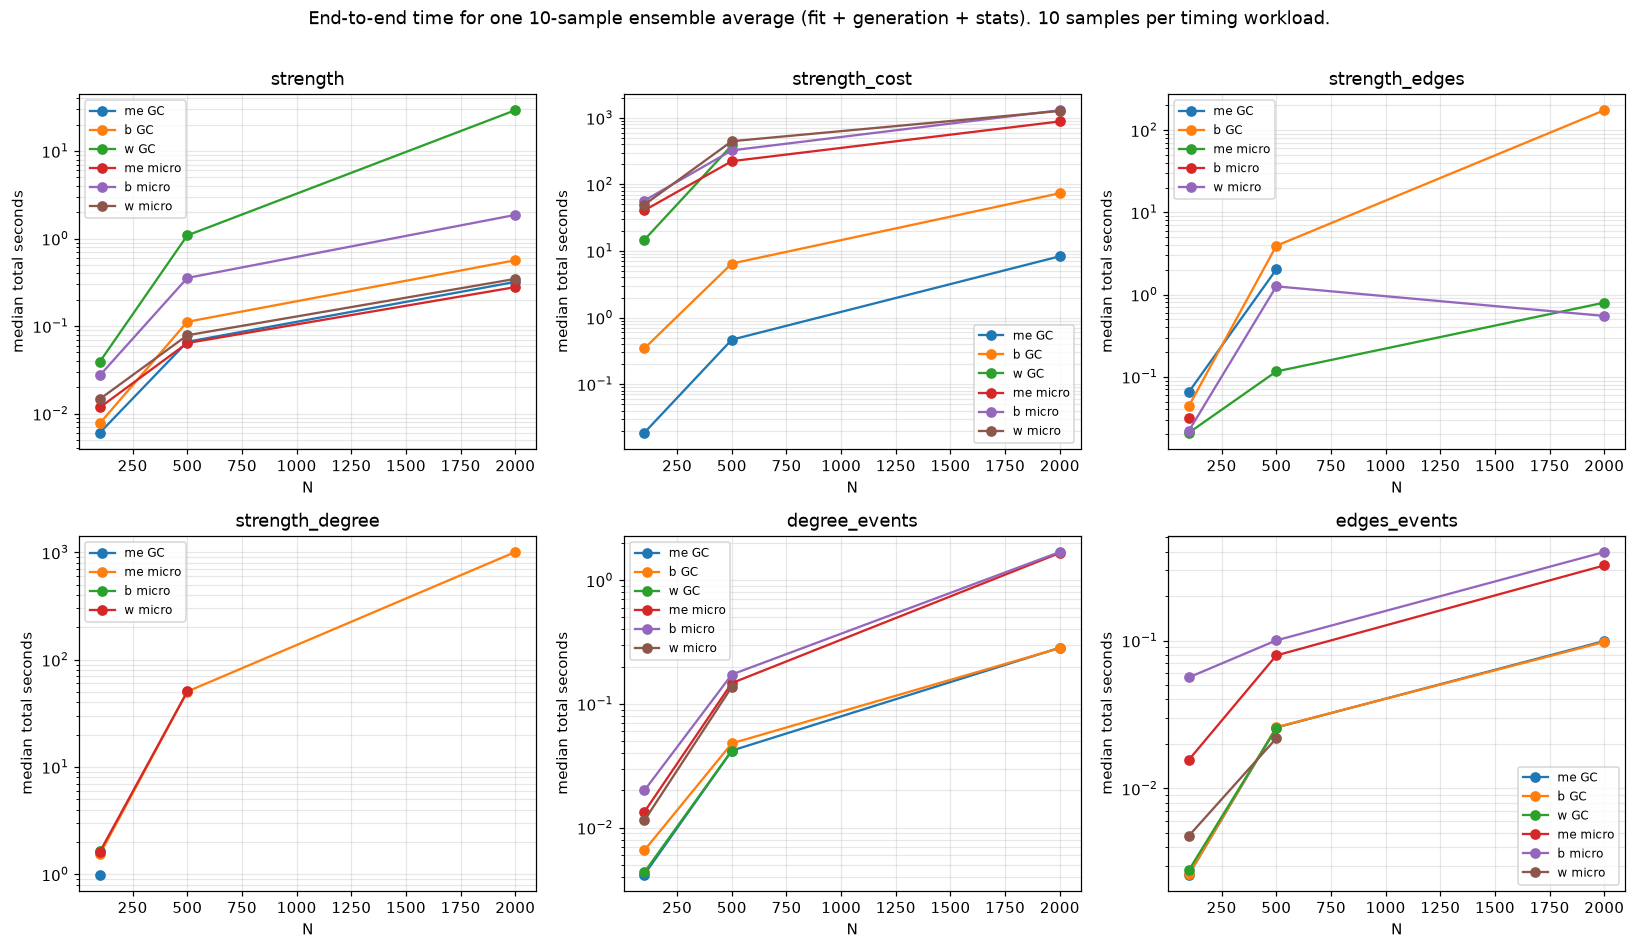

In [5]:
if timing is None:
    print("no timing results")
else:
    t = timing[timing["status"] == "ok"].copy()
    t["total_seconds"] = pd.to_numeric(t["total_seconds"])
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    axes = axes.ravel()
    for ax, cons in zip(axes, CONSTRAINTS, strict=False):
        cell = t[t["constraint"] == cons.value]
        for ens in (Ensemble.GRAND_CANONICAL, Ensemble.MICROCANONICAL):
            for fam in FAMILIES:
                sub = cell[(cell["ensemble"] == ens.value) & (cell["family"] == fam.value)]
                if sub.empty:
                    continue
                med = sub.groupby("node_count")["total_seconds"].median()
                ax.plot(med.index, med.values, "o-", label=f"{fam.value} {'GC' if ens is Ensemble.GRAND_CANONICAL else 'micro'}")
        ax.set_title(cons.value)
        ax.set_xlabel("N")
        ax.set_ylabel("median total seconds")
        ax.set_yscale("log")
        ax.legend(fontsize=8)
        ax.grid(True, which="both", alpha=0.3)
    fig.suptitle("End-to-end time for one 10-sample ensemble average (fit + generation + stats). 10 samples per timing workload.", y=1.01)
    fig.tight_layout()
    plt.show()


In [6]:
if timing is None:
    print("no timing results")
else:
    t = timing[timing["status"] == "ok"].copy()
    t["total_seconds"] = pd.to_numeric(t["total_seconds"])
    t["sampling_seconds"] = pd.to_numeric(t["sampling_seconds"])
    t["stats_seconds"] = pd.to_numeric(t["stats_seconds"])
    t["fit_seconds"] = pd.to_numeric(t["fit_seconds"])
    n500 = t[t["node_count"] == 500]

    def med(df, col):
        return float(pd.to_numeric(df[col]).median()) if len(df) else float("nan")

    rows = []
    for fam in FAMILIES:
        for cons in CONSTRAINTS:
            gc = n500[(n500.family == fam.value) & (n500.constraint == cons.value) & (n500.ensemble == Ensemble.GRAND_CANONICAL.value)]
            mc = n500[(n500.family == fam.value) & (n500.constraint == cons.value) & (n500.ensemble == Ensemble.MICROCANONICAL.value)]
            gc_e2e = med(gc, "total_seconds")
            gc_gen = med(gc, "sampling_seconds") + med(gc, "stats_seconds")
            mc_e2e = med(mc, "total_seconds")
            rows.append({
                "family": fam.value, "constraint": cons.value,
                "GC fit s": med(gc, "fit_seconds"),
                "GC 10-sample gen+stats s": gc_gen,
                "GC E2E s": gc_e2e,
                "micro 10-sample gen+stats s": mc_e2e,
                "micro / GC ratio": mc_e2e / gc_e2e if gc_e2e and np.isfinite(gc_e2e) else float("nan"),
            })
    scaling_table = pd.DataFrame(rows)
    print("N=500 scaling table (medians; 10 samples per timing workload)")
    display_scaling = scaling_table.copy()
    for c in display_scaling.columns:
        if c not in ("family", "constraint"):
            display_scaling[c] = display_scaling[c].round(2)
    print(display_scaling.to_string(index=False))


N=500 scaling table (medians; 10 samples per timing workload)
family      constraint  GC fit s  GC 10-sample gen+stats s  GC E2E s  micro 10-sample gen+stats s  micro / GC ratio
    me        strength      0.00                      0.07      0.07                         0.06              0.97
    me   strength_cost      0.38                      0.08      0.47                       223.31            479.98
    me  strength_edges      1.96                      0.06      2.02                         0.12              0.06
    me strength_degree       NaN                       NaN       NaN                        50.49               NaN
    me   degree_events      0.01                      0.03      0.04                         0.15              3.52
    me    edges_events      0.00                      0.03      0.03                         0.08              3.07
     b        strength      0.01                      0.10      0.11                         0.36              3.17
     b   s

In [7]:
if timing is None:
    print("no timing results")
else:
    t = timing[timing["status"] == "ok"].copy()
    t["total_seconds"] = pd.to_numeric(t["total_seconds"])
    med_total = t.groupby(["node_count", "family", "constraint", "ensemble"])["total_seconds"].median().reset_index()

    def alpha(n_from, n_to):
        sub = med_total[med_total.node_count.isin([n_from, n_to])]
        piv = sub.pivot(index=["family", "constraint", "ensemble"], columns="node_count", values="total_seconds")
        piv.columns = [str(c) for c in piv.columns]
        if str(n_from) not in piv.columns or str(n_to) not in piv.columns:
            return pd.Series(np.nan, index=piv.index)
        out = piv.apply(
            lambda r: np.log(r[str(n_to)] / r[str(n_from)]) / np.log(n_to / n_from),
            axis=1,
        )
        return out

    a1 = alpha(100, 500).rename("alpha_100_to_500")
    a2 = alpha(500, 2000).rename("alpha_500_to_2000")
    exponents = pd.concat([a1, a2], axis=1).reset_index()
    print("Observed effective scaling exponents alpha = log(t_N2 / t_N1) / log(N2 / N1).")
    print("These are empirical E2E exponents for this sparse regime, NOT Big-O complexity and NOT averaged into one number.")
    print(exponents.to_string(index=False))


Observed effective scaling exponents alpha = log(t_N2 / t_N1) / log(N2 / N1).
These are empirical E2E exponents for this sparse regime, NOT Big-O complexity and NOT averaged into one number.
family      constraint       ensemble  alpha_100_to_500  alpha_500_to_2000
     b   degree_events grandcanonical          1.237695           1.279890
     b   degree_events microcanonical          1.341355           1.645608
     b    edges_events grandcanonical          1.423239           0.958128
     b    edges_events microcanonical          0.357797           0.992593
     b        strength grandcanonical          1.659664           1.167404
     b        strength microcanonical          1.592340           1.195707
     b   strength_cost grandcanonical          1.823291           1.754610
     b   strength_cost microcanonical          1.078683           1.002333
     b strength_degree microcanonical               NaN                NaN
     b  strength_edges grandcanonical          2.788237    

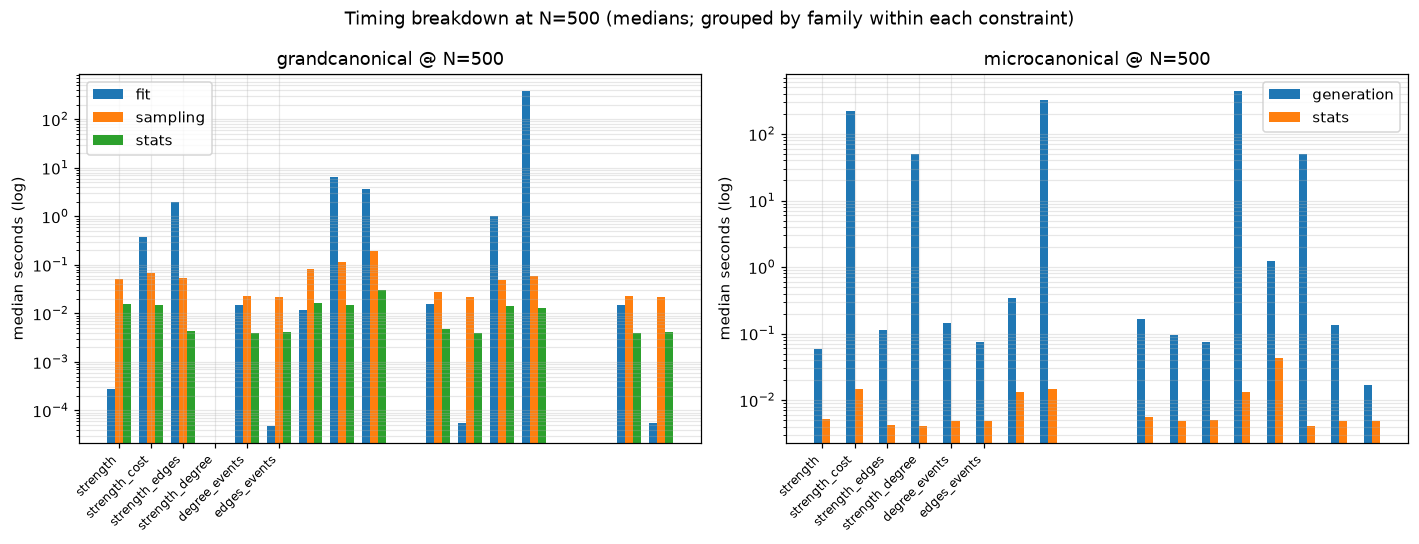

In [8]:
if timing is None:
    print("no timing results")
else:
    t = timing[timing["status"] == "ok"].copy()
    for c in ("fit_seconds", "sampling_seconds", "stats_seconds"):
        t[c] = pd.to_numeric(t[c])
    n500 = t[t.node_count == 500]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, ens in zip(axes, (Ensemble.GRAND_CANONICAL, Ensemble.MICROCANONICAL), strict=False):
        sub = n500[n500.ensemble == ens.value]
        fams = [f.value for f in FAMILIES]
        cons = [c.value for c in CONSTRAINTS]
        gc_fit = [sub[(sub.family == f) & (sub.constraint == c)]["fit_seconds"].median() for f in fams for c in cons]
        gc_sample = [sub[(sub.family == f) & (sub.constraint == c)]["sampling_seconds"].median() for f in fams for c in cons]
        gc_stats = [sub[(sub.family == f) & (sub.constraint == c)]["stats_seconds"].median() for f in fams for c in cons]
        x = np.arange(len(cons) * len(fams))
        width = 0.25
        if ens is Ensemble.GRAND_CANONICAL:
            ax.bar(x - width, gc_fit, width, label="fit")
            ax.bar(x, gc_sample, width, label="sampling")
            ax.bar(x + width, gc_stats, width, label="stats")
        else:
            ax.bar(x - width / 2, gc_sample, width, label="generation")
            ax.bar(x + width / 2, gc_stats, width, label="stats")
        ax.set_xticks(np.arange(len(cons)))
        ax.set_xticklabels(cons, rotation=45, ha="right", fontsize=8)
        ax.set_title(ens.value + " @ N=500")
        ax.set_yscale("log")
        ax.set_ylabel("median seconds (log)")
        ax.legend()
        ax.grid(True, which="both", alpha=0.3)
    fig.suptitle("Timing breakdown at N=500 (medians; grouped by family within each constraint)")
    fig.tight_layout()
    plt.show()


## 7. Higher-order observables

For every sample we store, per node: `strength_out/in`, `degree_out/in`,
$Y_2$ (`y2_out/in`), $k_{NN}$ (`k_nn_out/in`), $s_{NN}$ (`s_nn_out/in`), plus
globals $E$, $T$, `mean_positive_occupation = T / E`, and for `STRENGTH_COST`
the realized cost $C=\sum_{(i,j)\,\text{occupied}} t_{ij}\,
\sqrt{(x_i-x_j)^2+(y_i-y_j)^2}$.

Ensemble averages are node-wise means over the 10 samples; `mean_mc_se` is the
mean over nodes of the Monte Carlo standard error. No extra statistics
(clustering, motifs) are added in this task.


In [9]:
if science is None:
    print("no results")
else:
    cols = ["node_count", "family", "constraint", "observable", "direction",
            "ensemble", "mean_node_average", "mean_mc_se", "valid_node_count"]
    sub = science[science.node_count == 500].copy()
    for c in ("mean_node_average", "mean_mc_se"):
        sub[c] = pd.to_numeric(sub[c], errors="coerce")
    out = sub[sub.direction == "out"].pivot_table(
        index=["family", "constraint"], columns="observable",
        values="mean_node_average", aggfunc="first")
    print("N=500 ensemble-mean node averages (out-direction; strength/degree/Y2/kNN/sNN)")
    print(out.round(2).to_string())


N=500 ensemble-mean node averages (out-direction; strength/degree/Y2/kNN/sNN)
observable                Y2  degree     kNN     sNN  strength
family constraint                                             
b      degree_events    0.22    8.04   12.25   98.03     64.32
       edges_events     0.15    8.01    8.99   72.13     64.05
       strength         0.10   46.51  108.90  197.49     64.19
       strength_cost    0.10   43.14   98.71  199.55     64.14
       strength_edges   0.27    8.01   20.71  171.34     64.10
me     degree_events    0.24    7.91   12.08   97.65     63.50
       edges_events     0.16    7.97    8.95   72.38     63.74
       strength         0.10   45.62   99.64  184.27     64.00
       strength_cost    0.10   42.51   89.33  182.50     63.89
       strength_degree  0.61    8.00   11.46  113.37     64.00
       strength_edges   0.28    8.04   17.55  163.58     64.17
w      degree_events    0.30    7.93   12.08  100.78     63.08
       edges_events     0.23    8.01    

## 8. Constraint-by-constraint comparison

The disagreement metric between the micro and GC 10-sample ensemble means is
the symmetric normalized mean absolute difference

$$
D_{\mathrm{rel}}(x) = \frac{\frac{1}{m}\sum_i |\bar x_i^{micro} - \bar x_i^{GC}|}
{\frac{1}{m}\sum_i \frac{|\bar x_i^{micro}| + |\bar x_i^{GC}|}{2} + 10^{-12}},
$$

over nodes where both ensemble means are finite, together with the Spearman
rank correlation on the same nodes. For global observables, $D_{\mathrm{rel}}$
is the symmetric scalar relative difference and Spearman is not defined. Masked
cells mark observables that are hard-fixed (micro) or fitted (GC) validation
variables for that constraint, never displayed as zero disagreement.


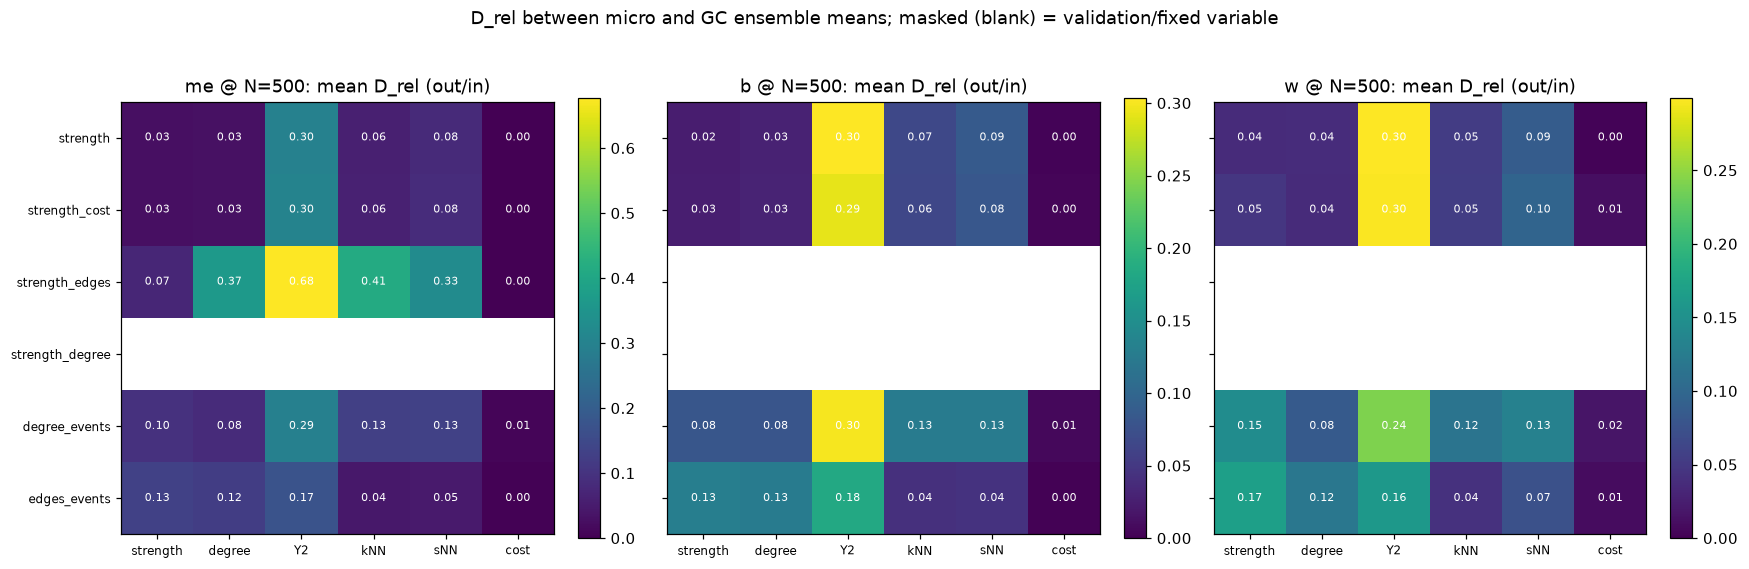

In [10]:
if comparison is None:
    print("no results")
else:
    c = comparison[comparison.node_count == 500].copy()
    for col in ("d_rel", "spearman"):
        c[col] = pd.to_numeric(c[col], errors="coerce")
    c["agg"] = c["observable"]  # observable name already includes direction

    orientation_cols = ["strength", "degree", "Y2", "kNN", "sNN", "cost"]
    row_labels = [cons.value for cons in CONSTRAINTS]
    mat = np.full((len(row_labels), len(orientation_cols)), np.nan)
    for i, cons in enumerate(CONSTRAINTS):
        cell = c[c.constraint == cons.value]
        for j, obs in enumerate(orientation_cols):
            rows_dir = cell[cell.observable == obs]
            vals = rows_dir["d_rel"]
            if vals.empty:
                mat[i, j] = np.nan
            else:
                mat[i, j] = float(vals.mean())
    fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
    for ax, fam in zip(axes, FAMILIES, strict=False):
        cell = c[c.family == fam.value]
        fmat = np.full_like(mat, np.nan)
        for i, cons in enumerate(CONSTRAINTS):
            rows_dir = cell[cell.constraint == cons.value]
            for j, obs in enumerate(orientation_cols):
                vals = rows_dir[rows_dir.observable == obs]["d_rel"]
                fmat[i, j] = float(vals.mean()) if len(vals) else np.nan
        im = ax.imshow(fmat, cmap="viridis", vmin=0, vmax=None)
        ax.set_xticks(range(len(orientation_cols))); ax.set_xticklabels(orientation_cols, fontsize=8)
        ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
        ax.set_title(f"{fam.value} @ N=500: mean D_rel (out/in)")
        for i in range(len(row_labels)):
            for j in range(len(orientation_cols)):
                if np.isfinite(fmat[i, j]):
                    ax.text(j, i, f"{fmat[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white")
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle("D_rel between micro and GC ensemble means; masked (blank) = validation/fixed variable")
    fig.tight_layout()
    plt.show()


In [11]:
HEATMAP_LABELS = ["strength", "degree", "Y2", "kNN", "sNN", "cost"]

def constraint_report(cons: Constraint, comp: pd.DataFrame | None, time_df: pd.DataFrame | None) -> str:
    if comp is None:
        return f"**{cons.value}.** no results."
    cell = comp[comp.constraint == cons.value].copy()
    for col in ("d_rel", "spearman"):
        cell[col] = pd.to_numeric(cell[col], errors="coerce")
    cell["agg"] = cell["observable"]
    primary_mask = cell["observable"].isin({
        Constraint.STRENGTH: ["E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_COST: ["cost", "E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_EDGES: ["degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_DEGREE: ["Y2", "kNN", "sNN", "mean_positive_occupation"],
        Constraint.DEGREE_EVENTS: ["strength", "Y2", "kNN", "sNN"],
        Constraint.EDGES_EVENTS: ["strength", "degree", "Y2", "kNN", "sNN"],
    }[cons])
    cell_p = cell[primary_mask].copy()
    if not cell_p.empty:
        top = cell_p.loc[cell_p["d_rel"].fillna(-1).idxmax()]
        largest = f"{top['observable']}({top['direction']}) D_rel={top['d_rel']:.3f} (Spearman {top['spearman']:.2f})" if pd.notna(top["d_rel"]) else "all NaN"
    else:
        largest = "n/a"

    def e2e(fam, ens, node_count):
        if time_df is None:
            return float("nan")
        sub = time_df[(time_df.family == fam) & (time_df.constraint == cons.value) & (time_df.ensemble == ens) & (time_df.node_count == node_count) & (time_df.status == "ok")]
        return float(pd.to_numeric(sub["total_seconds"]).median()) if len(sub) else float("nan")

    n500 = e2e("me", "microcanonical", 500)
    gc500 = e2e("me", "grandcanonical", 500)
    semantic = {
        Constraint.STRENGTH: "strengths matched in expectation (GC) vs exact (micro)",
        Constraint.STRENGTH_COST: "strengths + expected cost (GC) vs exact strengths + expected-cost gamma fit (micro)",
        Constraint.STRENGTH_EDGES: "strengths + E in expectation (GC) vs exact strengths + exact E (micro)",
        Constraint.STRENGTH_DEGREE: "strengths + degree sequence in expectation (GC) vs exact (micro)",
        Constraint.DEGREE_EVENTS: "degree sequences + T in expectation (GC) vs exact (micro)",
        Constraint.EDGES_EVENTS: "E + T in expectation (GC) vs exact (micro)",
    }[cons]
    return (f"**{cons.value}.**\n\n"
            f"**Semantics.** {semantic}.\n\n"
            f"**Runtime (N=500, ME, 10-sample E2E seconds).** GC {gc500:.2f} vs micro {n500:.2f}; "
            f"micro/GC ratio {n500 / gc500:.1f}x.\n\n"
            f"**Observable differences.** Largest non-fixed D_rel @ N=500: {largest}. "
            f"Full D_rel / Spearman values are in Figures 3-5 and the CSV files.\n\n"
            f"**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.\n")

if comparison is not None:
    for cons in CONSTRAINTS:
        from IPython.display import Markdown
        display(Markdown(constraint_report(cons, comparison, timing)))
else:
    print("no results")


**strength.**

**Semantics.** strengths matched in expectation (GC) vs exact (micro).

**Runtime (N=500, ME, 10-sample E2E seconds).** GC 0.07 vs micro 0.06; micro/GC ratio 1.0x.

**Observable differences.** Largest non-fixed D_rel @ N=500: Y2(in) D_rel=0.387 (Spearman 0.98). Full D_rel / Spearman values are in Figures 3-5 and the CSV files.

**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.


**strength_cost.**

**Semantics.** strengths + expected cost (GC) vs exact strengths + expected-cost gamma fit (micro).

**Runtime (N=500, ME, 10-sample E2E seconds).** GC 0.47 vs micro 223.31; micro/GC ratio 480.0x.

**Observable differences.** Largest non-fixed D_rel @ N=500: Y2(in) D_rel=0.348 (Spearman 0.97). Full D_rel / Spearman values are in Figures 3-5 and the CSV files.

**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.


**strength_edges.**

**Semantics.** strengths + E in expectation (GC) vs exact strengths + exact E (micro).

**Runtime (N=500, ME, 10-sample E2E seconds).** GC 2.02 vs micro 0.12; micro/GC ratio 0.1x.

**Observable differences.** Largest non-fixed D_rel @ N=500: Y2(out) D_rel=0.753 (Spearman -0.35). Full D_rel / Spearman values are in Figures 3-5 and the CSV files.

**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.


**strength_degree.**

**Semantics.** strengths + degree sequence in expectation (GC) vs exact (micro).

**Runtime (N=500, ME, 10-sample E2E seconds).** GC nan vs micro 50.49; micro/GC ratio nanx.

**Observable differences.** Largest non-fixed D_rel @ N=500: Y2(out) D_rel=0.799 (Spearman -0.03). Full D_rel / Spearman values are in Figures 3-5 and the CSV files.

**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.


**degree_events.**

**Semantics.** degree sequences + T in expectation (GC) vs exact (micro).

**Runtime (N=500, ME, 10-sample E2E seconds).** GC 0.04 vs micro 0.15; micro/GC ratio 3.5x.

**Observable differences.** Largest non-fixed D_rel @ N=500: Y2(in) D_rel=0.338 (Spearman 0.95). Full D_rel / Spearman values are in Figures 3-5 and the CSV files.

**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.


**edges_events.**

**Semantics.** E + T in expectation (GC) vs exact (micro).

**Runtime (N=500, ME, 10-sample E2E seconds).** GC 0.03 vs micro 0.08; micro/GC ratio 3.1x.

**Observable differences.** Largest non-fixed D_rel @ N=500: Y2(out) D_rel=0.188 (Spearman -0.11). Full D_rel / Spearman values are in Figures 3-5 and the CSV files.

**Practical takeaway.** See the tables and figures; conclusions are only drawn from actual values.


### 8.1 Strength

**Semantics.** Strengths are matched in expectation by GC and exactly by micro.

**Runtime.** Real numbers are computed in the summary cells above from the
timing CSV; nothing here is hard-coded.

**Observable differences.** $E$, degree, $Y_2$, $k_{NN}$, $s_{NN}$ are all
non-fixed here, so they measure how much the two ensembles differ when only
magnitude constraints are imposed.

**Practical takeaway.** See the live tables/figures.


### 8.2 Strength + expected cost

**Semantics.** GC matches strengths and expected cost; micro fixes strengths
exactly and matches cost in expectation via its internal gamma fit. Cost is
**not** exact in micro.

**Runtime.** As above, live from the timing CSV.

**Observable differences.** Realized total cost plus all support observables.

**Practical takeaway.** See the live tables/figures.


### 8.3 Strength + edges

**Semantics.** GC: strengths and $E$ in expectation; micro: exact strengths and
exact $E$.

**Runtime.** Live from the timing CSV.

**Observable differences.** Degree, $Y_2$, $k_{NN}$, $s_{NN}$.

**Practical takeaway.** See the live tables/figures.


### 8.4 Strength + degree

**Semantics.** GC matches strengths and the degree sequence in expectation;
micro fixes both exactly.

**Runtime.** Live from the timing CSV.

**Observable differences.** $Y_2$, $k_{NN}$, $s_{NN}$, `mean_positive_occupation`.

**Practical takeaway.** See the live tables/figures.


### 8.5 Degree + events

**Semantics.** GC matches degrees and $T$ in expectation; micro fixes the
degree sequences and $T$ exactly.

**Runtime.** Live from the timing CSV.

**Observable differences.** Strength, $Y_2$, $k_{NN}$, $s_{NN}$.

**Practical takeaway.** See the live tables/figures.


### 8.6 Edges + events

**Semantics.** GC matches $E$ and $T$ in expectation; micro fixes both exactly
(direct sampler).

**Runtime.** Live from the timing CSV.

**Observable differences.** Strength and degree sequences are the main
non-fixed observables.

**Practical takeaway.** See the live tables/figures.


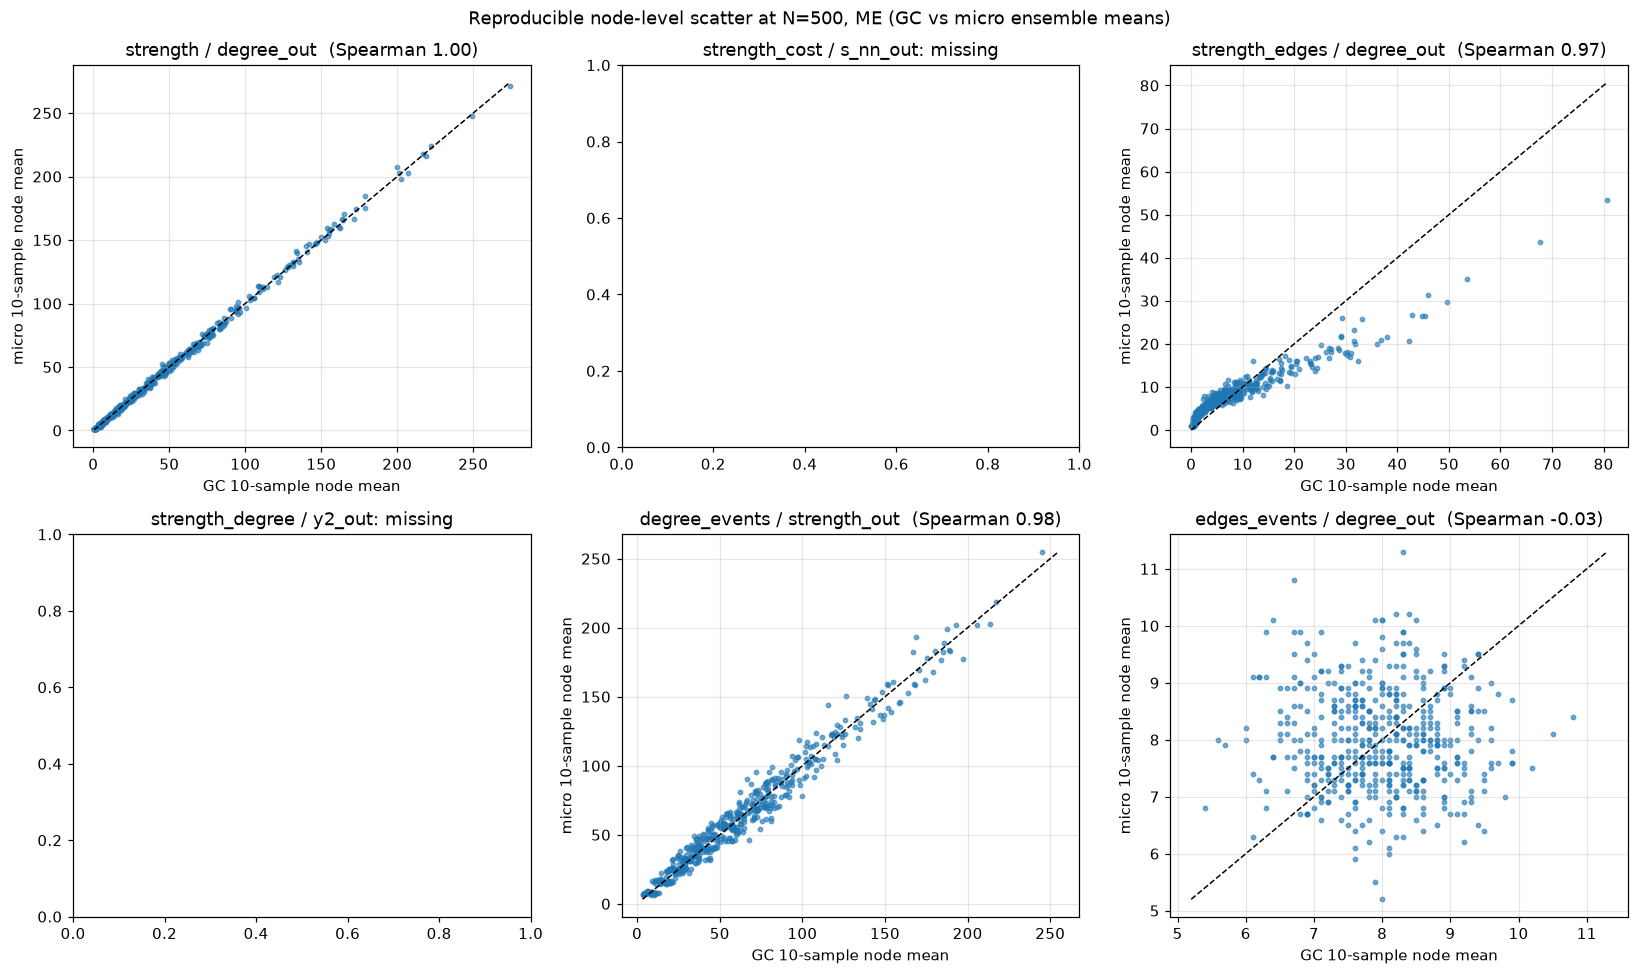

In [12]:
if mins:
    panel_specs = [
        (Constraint.STRENGTH, "degree_out"),
        (Constraint.STRENGTH_COST, "s_nn_out"),
        (Constraint.STRENGTH_EDGES, "degree_out"),
        (Constraint.STRENGTH_DEGREE, "y2_out"),
        (Constraint.DEGREE_EVENTS, "strength_out"),
        (Constraint.EDGES_EVENTS, "degree_out"),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()
    for ax, (cons, obs) in zip(axes, panel_specs, strict=False):
        gc_key = f"500-me-{cons.value}-grandcanonical|{obs}|mean"
        mc_key = f"500-me-{cons.value}-microcanonical|{obs}|mean"
        if gc_key not in mins or mc_key not in mins:
            ax.set_title(f"{cons.value} / {obs}: missing")
            continue
        g = mins[gc_key]
        m = mins[mc_key]
        valid = np.isfinite(g) & np.isfinite(m)
        ax.scatter(g[valid], m[valid], s=8, alpha=0.6)
        lo = min(np.nanmin(g), np.nanmin(m)); hi = max(np.nanmax(g), np.nanmax(m))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        rho = _spearman(g[valid], m[valid])
        ax.set_title(f"{cons.value} / {obs}  (Spearman {rho:.2f})")
        ax.set_xlabel("GC 10-sample node mean")
        ax.set_ylabel("micro 10-sample node mean")
        ax.grid(alpha=0.3)
    fig.suptitle("Reproducible node-level scatter at N=500, ME (GC vs micro ensemble means)")
    fig.tight_layout()
    plt.show()
else:
    print("no per-node means available")


## 9. Scaling with N

Lower panel rows mirror Figure 4: $D_{\mathrm{rel}}$ for the primary
(non-fixed) observables at $N=100,500,2000$ in the fixed sparse regime.

> These three points show empirical finite-size behavior in the fixed-sparse
> regime; they do **not** establish an asymptotic scaling law.

Effective E2E exponents were printed in [section 6](#6-end-to-end-computational-cost);
they are *observed* exponents, not Big-O complexity.


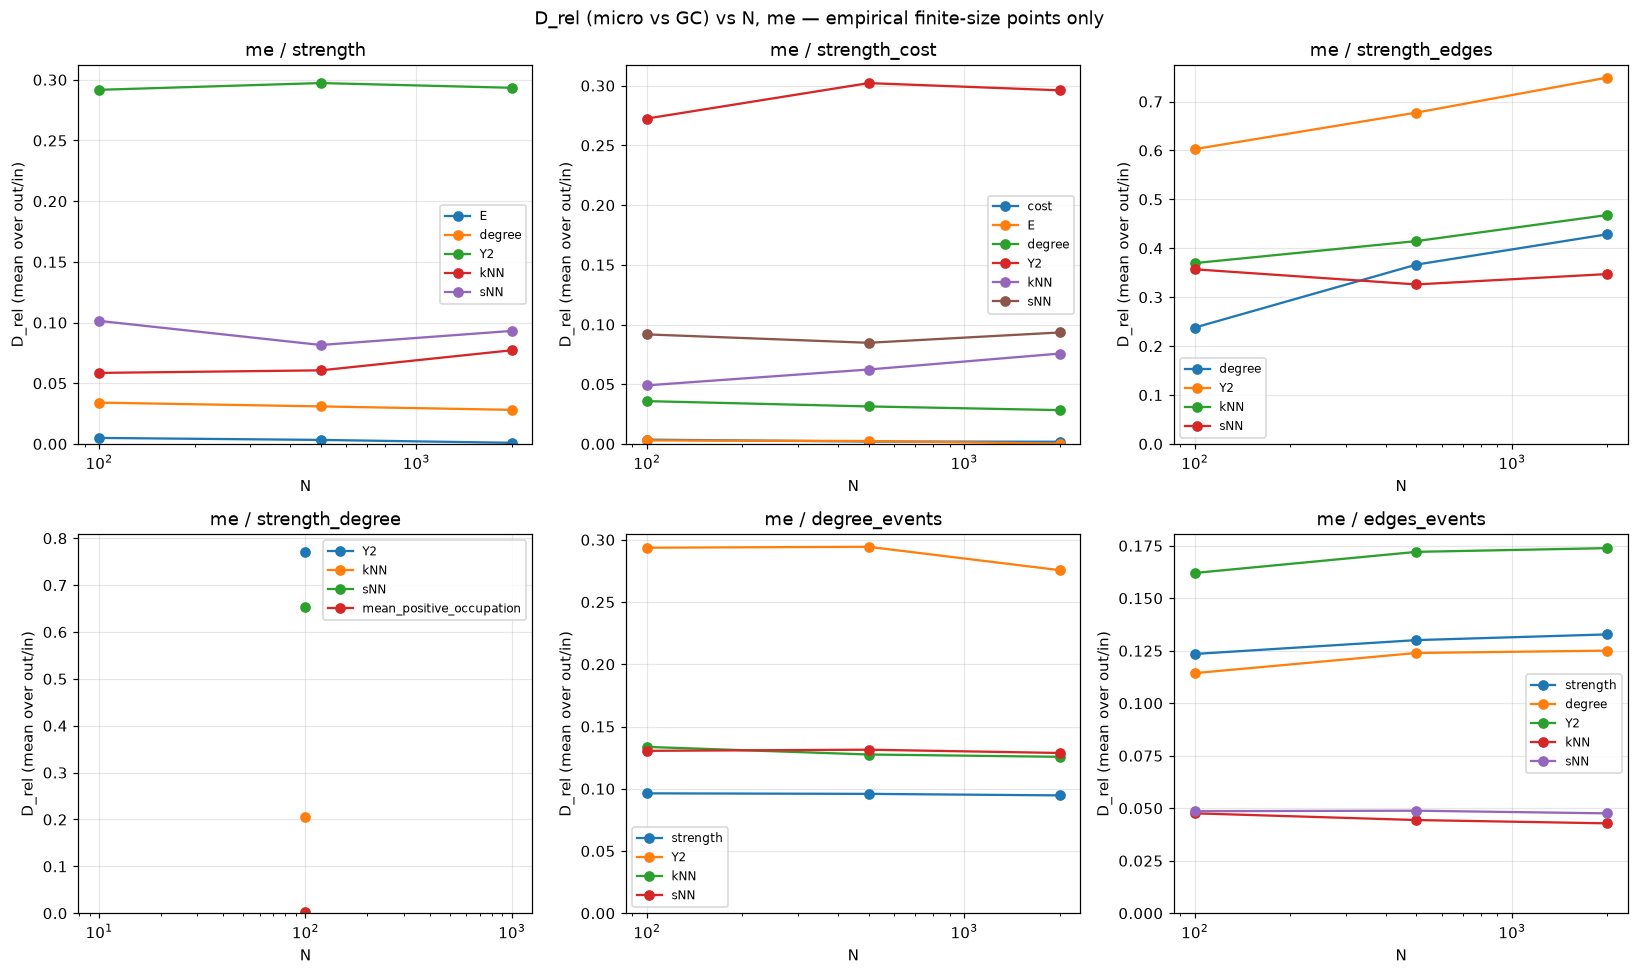

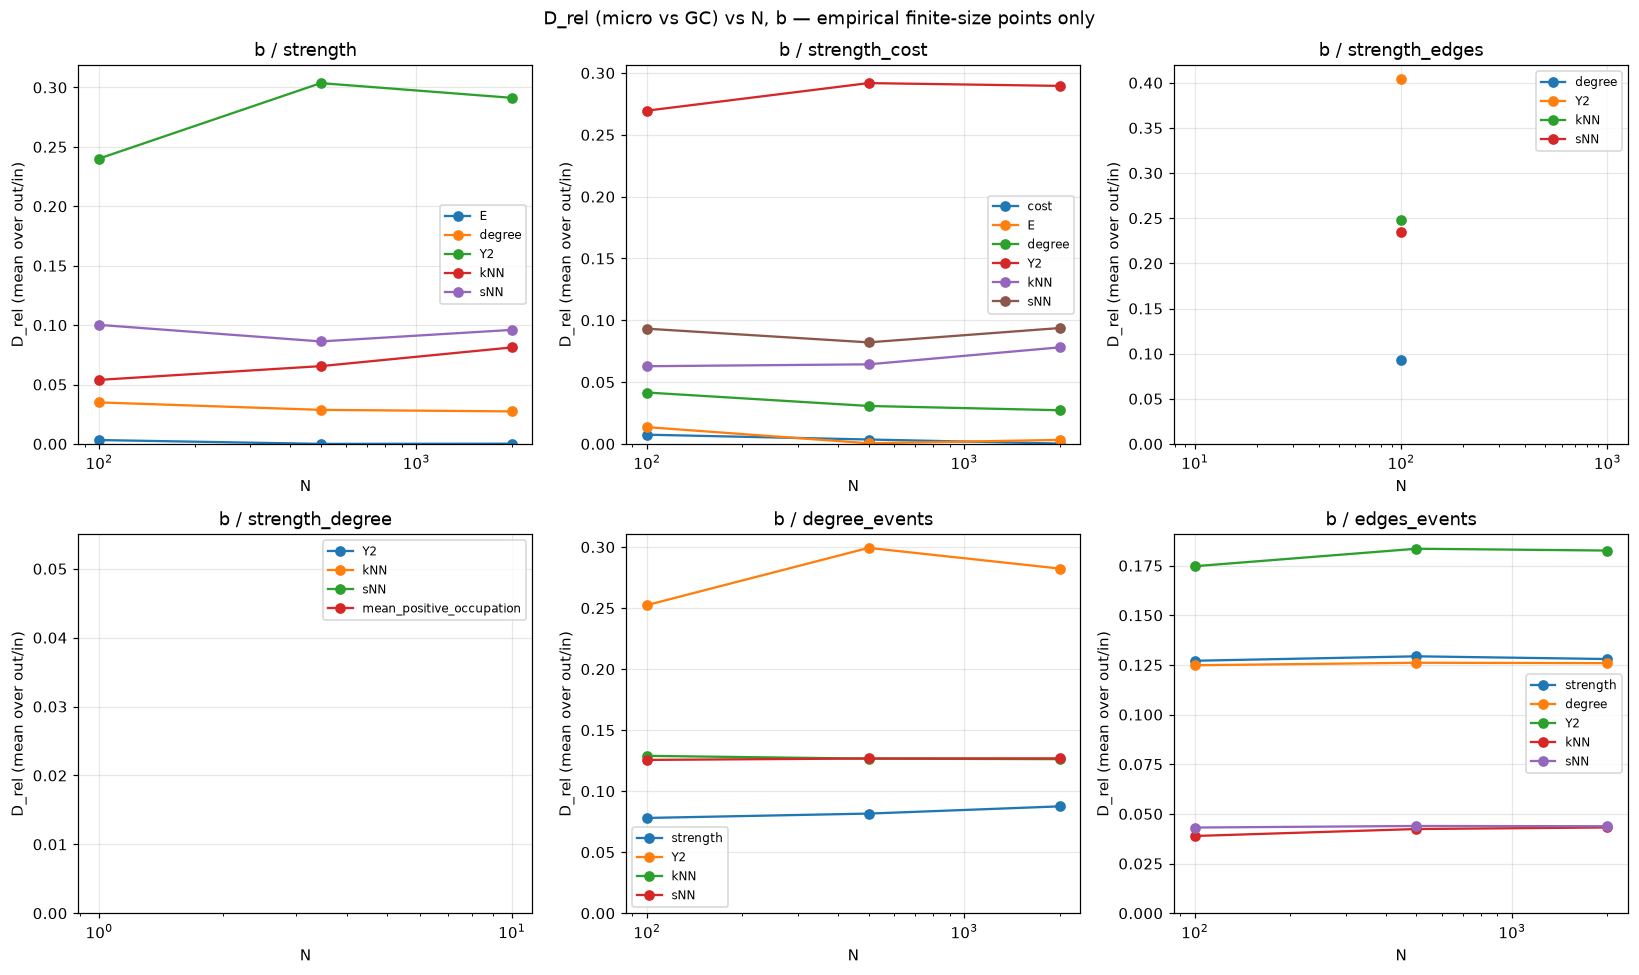

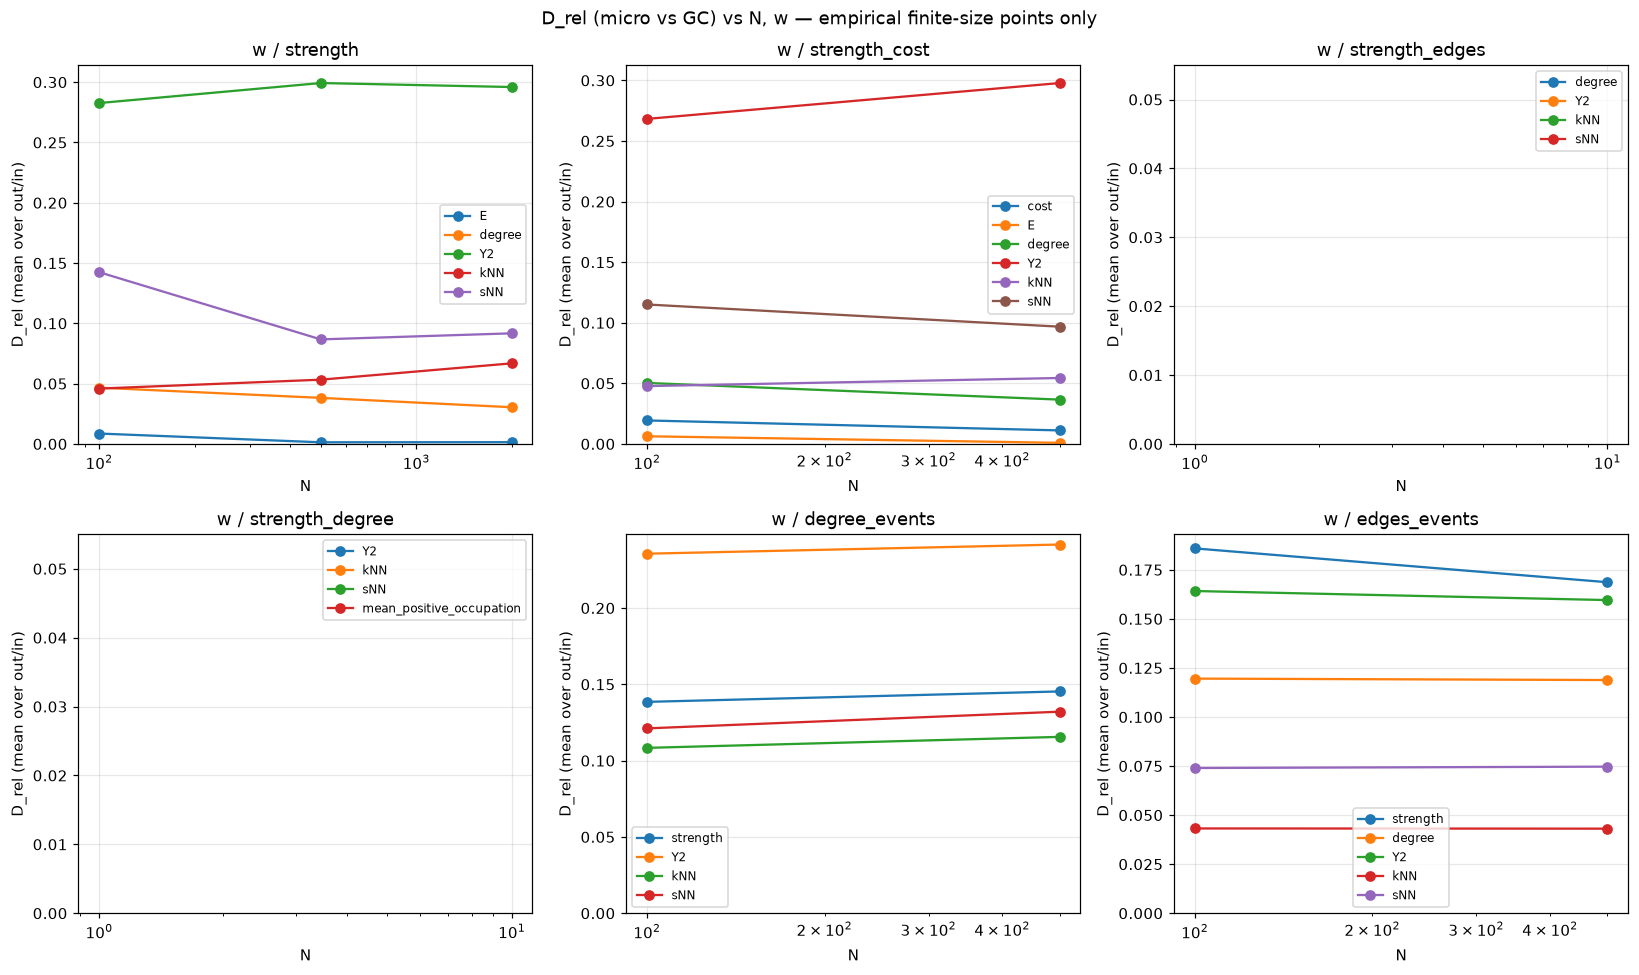

In [13]:
if comparison is None:
    print("no results")
else:
    c = comparison.copy()
    for col in ("d_rel",):
        c[col] = pd.to_numeric(c[col], errors="coerce")
    obs_names = {
        Constraint.STRENGTH: ["E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_COST: ["cost", "E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_EDGES: ["degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_DEGREE: ["Y2", "kNN", "sNN", "mean_positive_occupation"],
        Constraint.DEGREE_EVENTS: ["strength", "Y2", "kNN", "sNN"],
        Constraint.EDGES_EVENTS: ["strength", "degree", "Y2", "kNN", "sNN"],
    }
    for fam in FAMILIES:
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        axes = axes.ravel()
        for ax, cons in zip(axes, CONSTRAINTS, strict=False):
            cell = c[(c.family == fam.value) & (c.constraint == cons.value)]
            for obs in obs_names[cons]:
                sub = cell[cell.observable == obs]
                agg = sub.groupby("node_count")["d_rel"].mean()
                ax.plot(agg.index, agg.values, "o-", label=obs)
            ax.set_title(f"{fam.value} / {cons.value}")
            ax.set_xscale("log")
            ax.set_xlabel("N")
            ax.set_ylabel("D_rel (mean over out/in)")
            ax.set_ylim(bottom=0)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)
        fig.suptitle(f"D_rel (micro vs GC) vs N, {fam.value} — empirical finite-size points only")
        fig.tight_layout()
        plt.show()


## 10. Sensitivity to sparsity

One small ME-only sensitivity experiment at $N=500$,
$T/E\approx 8$, with `average_degree` $\in\{3,8,20\}$
(observed seeds `142 + int(avg_degree)`). It shows whether the finite-size
micro-vs-GC differences are especially strong in sparse networks or
qualitatively similar when the mean degree changes. **This is not** a general
family-wide result.


/tmp/ipykernel_210015/3042500669.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


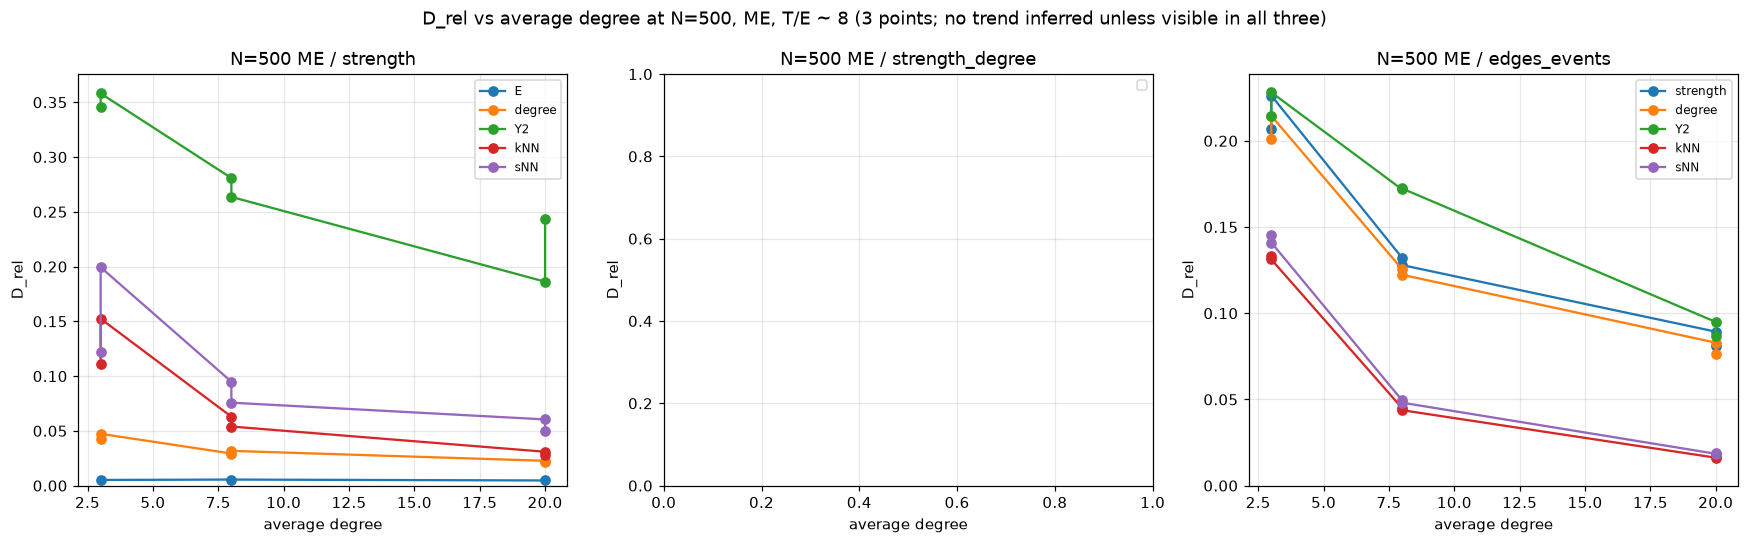

In [14]:
if sparsity is None:
    print("no sparsity results")
else:
    s = sparsity.copy()
    for col in ("d_rel", "average_degree"):
        s[col] = pd.to_numeric(s[col], errors="coerce")
    cons_primary = {
        Constraint.STRENGTH: ["E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_DEGREE: ["Y2", "kNN", "sNN", "mean_positive_occupation"],
        Constraint.EDGES_EVENTS: ["strength", "degree", "Y2", "kNN", "sNN"],
    }
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, cons in zip(axes, (Constraint.STRENGTH, Constraint.STRENGTH_DEGREE, Constraint.EDGES_EVENTS), strict=False):
        cell = s[s.constraint == cons.value].dropna(subset=["d_rel"])
        for obs in cons_primary[cons]:
            sub = cell[cell.observable == obs]
            if sub.empty:
                continue
            ax.plot(sub.average_degree, sub.d_rel, "o-", label=obs)
        ax.set_title(f"N=500 ME / {cons.value}")
        ax.set_xlabel("average degree")
        ax.set_ylabel("D_rel")
        ax.set_ylim(bottom=0)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    fig.suptitle("D_rel vs average degree at N=500, ME, T/E ~ 8 (3 points; no trend inferred unless visible in all three)")
    fig.tight_layout()
    plt.show()


## 11. Relation to ensemble equivalence

The theoretical ensemble-equivalence page
([Ensemble equivalence](../../science/ensemble-equivalence.md)) studies the
fixed-$N$, large-$T$ concentration question: the GC law conditioned on the
hard constraints *is* the microcanonical target by an exact identity, and
differences between the unconditional ensembles can shrink for some
observables as $T\to\infty$.

This notebook studies the **opposite** regime: $N\in\{100,500,2000\}$,
$\langle k\rangle\approx 8$, $T/E\approx 8$, i.e. finite $N$ and finite
$T$. Therefore:

- The notebook is **not** a numerical test of the fixed-$N$, large-$T$ theorem.
- It is a finite-size comparison of the current hard and soft MENoBiS models
  under a sparse scaling regime.

$$
\text{same target constraints}
\not\Rightarrow
\text{same finite-size probability measure}
\not\Rightarrow
\text{same higher-order observables}.
$$

Micro constraints are exact where documented; GC constraints are matched in
expectation; nonlinear observables need not agree. The existing
fixed-$N$/increasing-$T$ experiment
(`tests/test_menobis_ensemble_exact.py`,
`tests/test_menobis_ensemble_equivalence.py`) is a separate theory-driven
concentration question and is **not** used here to prove or disprove anything.


## 12. Practical model-selection guide

The table below summarizes, per family $\times$ constraint at $N=500$: GC and
micro 10-sample E2E seconds, the micro/GC ratio, the largest non-fixed
$D_{\mathrm{rel}}$ (with its observable), the 100-to-2000 $D_{\mathrm{rel}}$
trend, and a practical note. Trends follow the data rule
(`decreases` if $d_{2000}<0.8\,d_{100}$, `increases` if
$d_{2000}>1.2\,d_{100}$, else `roughly stable`).


In [15]:
if comparison is None or timing is None:
    print("no results")
else:
    comp = comparison.copy()
    t = timing[timing.status == "ok"].copy()
    for col in ("total_seconds", "d_rel"):
        if col in comp.columns:
            comp[col] = pd.to_numeric(comp[col], errors="coerce")
    t["total_seconds"] = pd.to_numeric(t["total_seconds"])

    obs_names = {
        Constraint.STRENGTH: ["E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_COST: ["cost", "E", "degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_EDGES: ["degree", "Y2", "kNN", "sNN"],
        Constraint.STRENGTH_DEGREE: ["Y2", "kNN", "sNN", "mean_positive_occupation"],
        Constraint.DEGREE_EVENTS: ["strength", "Y2", "kNN", "sNN"],
        Constraint.EDGES_EVENTS: ["strength", "degree", "Y2", "kNN", "sNN"],
    }

    def med_time(fam, cons, ens, node_count):
        sub = t[(t.family == fam) & (t.constraint == cons.value) & (t.ensemble == ens) & (t.node_count == node_count)]
        return float(sub["total_seconds"].median()) if len(sub) else float("nan")

    def largest_drel(fam, cons, node_count):
        cell = comp[(comp.family == fam) & (comp.constraint == cons.value) & (comp.node_count == node_count)]
        cell = cell[cell.observable.isin(obs_names[cons])]
        if cell.empty:
            return float("nan"), ""
        cell = cell.dropna(subset=["d_rel"])
        if cell.empty:
            return float("nan"), ""
        top = cell.loc[cell["d_rel"].idxmax()]
        return float(top["d_rel"]), f"{top['observable']}({top['direction']})"

    rows = []
    for fam in FAMILIES:
        for cons in CONSTRAINTS:
            gc500 = med_time(fam.value, cons, Ensemble.GRAND_CANONICAL.value, 500)
            mc500 = med_time(fam.value, cons, Ensemble.MICROCANONICAL.value, 500)
            ratio = mc500 / gc500 if gc500 and np.isfinite(gc500) else float("nan")
            d500, obs500 = largest_drel(fam.value, cons, 500)
            d100, _ = largest_drel(fam.value, cons, 100)
            d2000, _ = largest_drel(fam.value, cons, 2000)
            if np.isfinite(d100) and np.isfinite(d2000):
                if d2000 < 0.8 * d100:
                    trend = "decreases"
                elif d2000 > 1.2 * d100:
                    trend = "increases"
                else:
                    trend = "roughly stable"
            else:
                trend = "n/a"
            note = "micro cheaper/thin" if np.isfinite(ratio) and ratio < 1 else "micro heavier"
            if not np.isfinite(ratio):
                note = "one ensemble unavailable"
            rows.append({
                "Family": fam.value, "Constraint": cons.value,
                "GC E2E @ N=500": gc500, "Micro E2E @ N=500": mc500,
                "Micro/GC ratio": ratio,
                "Largest non-fixed D_rel @ N=500": d500,
                "Observable with largest D_rel": obs500,
                "D_rel trend 100->2000": trend,
                "Practical note": note,
            })
    final_table = pd.DataFrame(rows)
    shown = final_table.copy()
    for col in ("GC E2E @ N=500", "Micro E2E @ N=500", "Micro/GC ratio", "Largest non-fixed D_rel @ N=500"):
        shown[col] = pd.to_numeric(shown[col], errors="coerce").round(2)
    print(shown.to_string(index=False))


Family      Constraint  GC E2E @ N=500  Micro E2E @ N=500  Micro/GC ratio  Largest non-fixed D_rel @ N=500 Observable with largest D_rel D_rel trend 100->2000           Practical note
    me        strength            0.07               0.06            0.97                             0.32                       Y2(out)             decreases       micro cheaper/thin
    me   strength_cost            0.47             223.31          479.98                             0.30                       Y2(out)        roughly stable            micro heavier
    me  strength_edges            2.02               0.12            0.06                             0.69                       Y2(out)             increases       micro cheaper/thin
    me strength_degree             NaN              50.49             NaN                              NaN                                                 n/a one ensemble unavailable
    me   degree_events            0.04               0.15            3.52       

### Notes on interpretation

- Results are reported as *finite-size agreement/disagreement* or *practical
  similarity/difference*, always with the actual $D_{\mathrm{rel}}$, Spearman,
  and timing values. No cell is labeled "equivalent/non-equivalent".
- Nothing here assumes ME is closer to micro than W, that micro is always
  slower, that GC always wins after fit amortization, that increasing $N$ brings
  the ensembles closer, that fixed $(s,k)$ implies equal $Y_2$, or that
  sparsity necessarily increases disagreement.
- 10 samples are used everywhere; the MC standard error quantifies the sampling
  noise, and 10 samples do **not** prove convergence.
- Where the MCMC budget gate found instability (`unstable_at_max_budget`) or a
  feasibility cap was applied, the affected micro cells carry an explicit note
  (metadata `budget_gate`, `budget_caps`) and their higher-order micro values
  must be read with that caveat.
